# Prediccion de número de peregrinos por día 



In [1]:
import pandas as pd
import numpy as np
from prophet import Prophet

import matplotlib.pyplot as plt
%matplotlib inline
import datetime
from datetime import timedelta



Importing plotly failed. Interactive plots will not work.


In [2]:
df_datos = pd.read_csv('peregrinos_para_prophet.csv')

In [3]:
df_datos[df_datos['y']>6000]

,Unnamed: 0,ds,y
217,217,2010-08-06,6560


In [4]:
df_datos[df_datos['y']<0]

,Unnamed: 0,ds,y


In [5]:
df_datos.reset_index()

,index,Unnamed: 0,ds,y
0,0,0,2010-01-01,115
1,1,1,2010-01-02,53
2,2,2,2010-01-03,25
3,3,3,2010-01-04,70
4,4,4,2010-01-05,56
...,...,...,...,...
4743,4743,4743,2022-12-27,69
4744,4744,4744,2022-12-28,69
4745,4745,4745,2022-12-29,93
4746,4746,4746,2022-12-30,159


In [6]:
df_datos = df_datos[['ds','y']]
df_datos.head()

,ds,y
0,2010-01-01,115
1,2010-01-02,53
2,2010-01-03,25
3,2010-01-04,70
4,2010-01-05,56


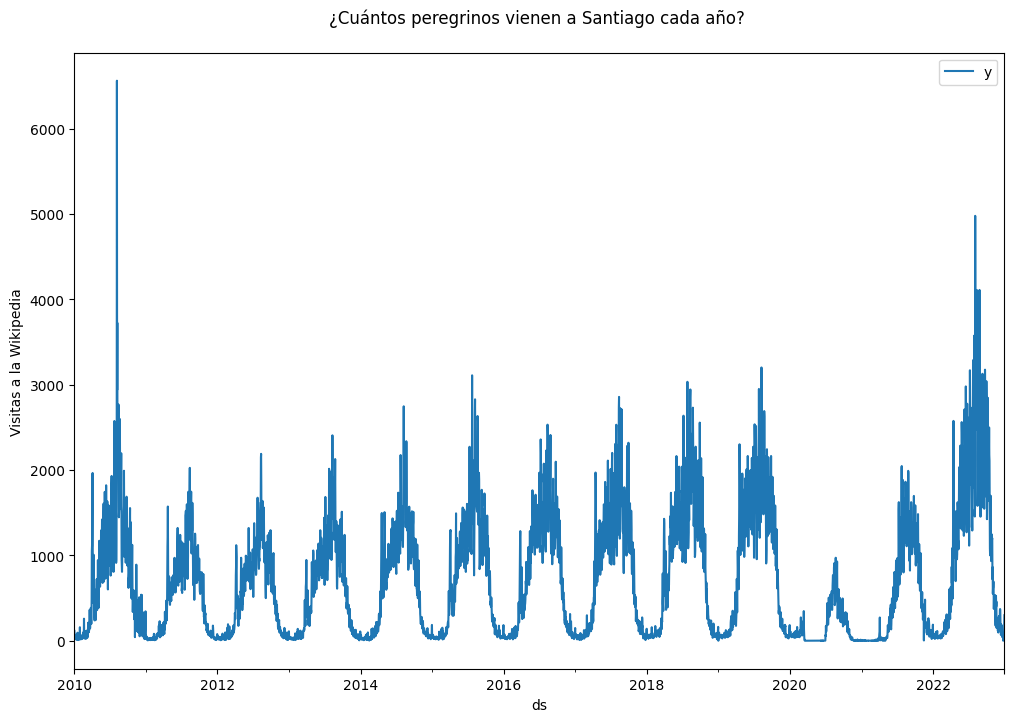

In [7]:
## Representamos nuestra serie temporal
df_datos['ds']=pd.to_datetime(df_datos['ds'])
ax = df_datos.set_index('ds').plot(figsize = (12, 8),
                                      title = '¿Cuántos peregrinos vienen a Santiago cada año? \n')
ax.set_ylabel('Visitas a la Wikipedia')
ax.set_xlabel('ds')

plt.show()

In [10]:
modelo = Prophet()


In [11]:
modelo.fit(df_datos)

20:44:35 - cmdstanpy - INFO - Chain [1] start processing
20:44:35 - cmdstanpy - INFO - Chain [1] done processing
20:44:35 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 6 Unknown error: -6
Optimization terminated abnormally. Falling back to Newton.
20:44:35 - cmdstanpy - INFO - Chain [1] start processing
20:44:35 - cmdstanpy - INFO - Chain [1] done processing
20:44:35 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 6 Unknown error: -6


RuntimeError: Error during optimization: console log output:

dyld[25981]: Library not loaded: '@rpath/libtbb.dylib'
  Referenced from: '/opt/anaconda3/envs/prophet39/lib/python3.9/site-packages/prophet/stan_model/prophet_model.bin'
  Reason: tried: '/private/var/folders/rv/z0yvw1vn57j7rg7v3j11b_3r0000gn/T/pip-install-lcswezam/prophet_dae3b1c23eb04e17bc9d35679c4efc77/build/lib.macosx-11.1-arm64-cpython-39/prophet/stan_model/cmdstan-2.26.1/stan/lib/stan_math/lib/tbb/libtbb.dylib' (no such file), '/private/var/folders/rv/z0yvw1vn57j7rg7v3j11b_3r0000gn/T/pip-install-lcswezam/prophet_dae3b1c23eb04e17bc9d35679c4efc77/build/lib.macosx-11.1-arm64-cpython-39/prophet/stan_model/cmdstan-2.26.1/stan/lib/stan_math/lib/tbb/libtbb.dylib' (no such file), '/usr/local/lib/libtbb.dylib' (no such file), '/usr/lib/libtbb.dylib' (no such file)


In [62]:
futuro = modelo.make_future_dataframe(periods=365)

In [63]:
futuro.tail()

,ds
5108,2023-12-27
5109,2023-12-28
5110,2023-12-29
5111,2023-12-30
5112,2023-12-31


In [13]:
prevision = modelo.predict(futuro)

/opt/anaconda3/lib/python3.9/site-packages/prophet/forecaster.py:896: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  components = components.append(new_comp)
/opt/anaconda3/lib/python3.9/site-packages/prophet/forecaster.py:896: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  components = components.append(new_comp)


In [14]:
prevision.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
5108,2023-12-27,2055.127138,819.357478,1720.066386,1826.723777,2301.556791,-777.040114,-777.040114,-777.040114,-95.189893,-95.189893,-95.189893,-681.850221,-681.850221,-681.850221,0.0,0.0,0.0,1278.087024
5109,2023-12-28,2056.783274,945.509921,1860.252122,1827.300675,2303.901867,-684.314470,-684.314470,-684.314470,-5.625913,-5.625913,-5.625913,-678.688557,-678.688557,-678.688557,0.0,0.0,0.0,1372.468804
5110,2023-12-29,2058.439410,1110.983760,2020.899061,1827.982800,2306.338894,-483.730953,-483.730953,-483.730953,191.061446,191.061446,191.061446,-674.792398,-674.792398,-674.792398,0.0,0.0,0.0,1574.708458
5111,2023-12-30,2060.095547,1103.382613,2031.403915,1829.000635,2308.775922,-512.521608,-512.521608,-512.521608,157.757520,157.757520,157.757520,-670.279128,-670.279128,-670.279128,0.0,0.0,0.0,1547.573939
5112,2023-12-31,2061.751683,991.342316,1881.090452,1829.522569,2311.212950,-648.827207,-648.827207,-648.827207,16.454513,16.454513,16.454513,-665.281720,-665.281720,-665.281720,0.0,0.0,0.0,1412.924476


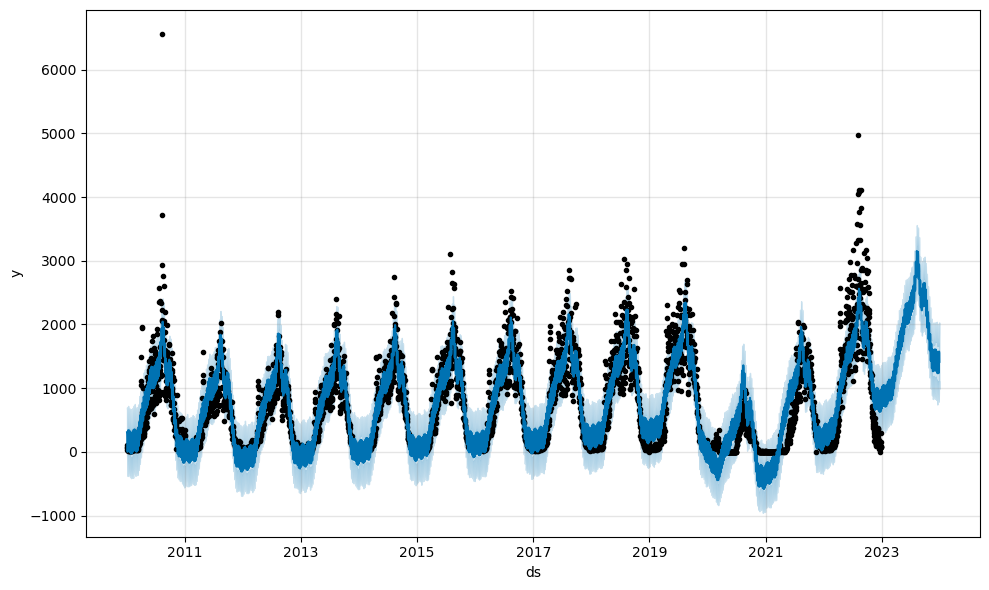

In [15]:
modelo.plot(prevision);

/opt/anaconda3/lib/python3.9/site-packages/prophet/forecaster.py:896: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  components = components.append(new_comp)
/opt/anaconda3/lib/python3.9/site-packages/prophet/forecaster.py:896: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  components = components.append(new_comp)


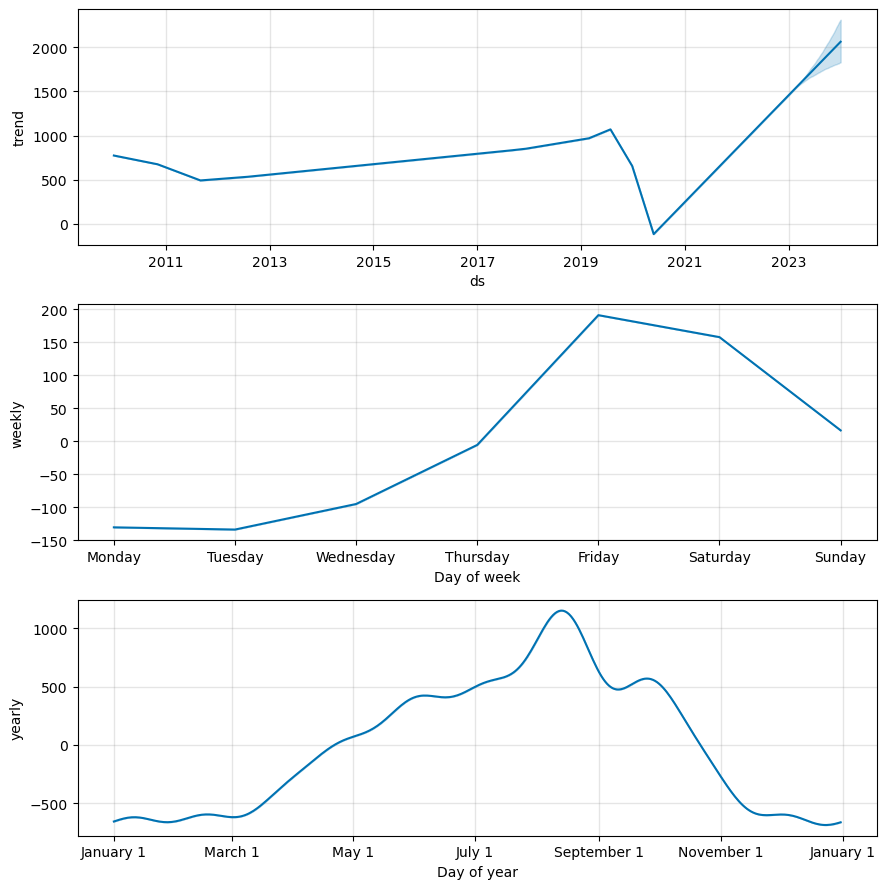

In [16]:
modelo.plot_components(prevision, weekly_start = 1);

In [20]:
confinamiento = pd.DataFrame()

confinamiento['ds'] = pd.date_range(start='2020-03-14', end='2020-06-21')

confinamiento = pd.DataFrame({
  'holiday': 'confinamiento',
  'ds': confinamiento['ds'],
  'lower_window': 0,
  'upper_window': 1,
})

In [21]:
xacobeo10 = pd.DataFrame()

xacobeo10['ds'] = pd.date_range(start='2010-01-01', end='2010-12-31')



In [49]:
xacobeo10 = pd.DataFrame()

xacobeo10['ds'] = pd.date_range(start='2010-01-01', end='2010-12-31')


xacobeo21 = pd.DataFrame()

xacobeo21['ds'] = pd.date_range(start='2021-01-01', end='2021-12-31')



xacobeo22 = pd.DataFrame()

xacobeo22['ds'] = pd.date_range(start='2022-01-01', end='2022-12-31')

xacobeo = pd.DataFrame()


xacobeo= pd.concat([xacobeo,xacobeo21,xacobeo22])

In [50]:
xacobeo = pd.DataFrame({
  'holiday': 'xacobeo',
  'ds': xacobeo['ds'],
  'lower_window': 0,
  'upper_window': 1,
})

In [26]:
fechas = []

for year in range(2010, 2024):
    fecha = datetime.date(year, 7, 25)
    if fecha.weekday() == 6:
        # El día de Santiago coincide con un domingo
        fechas.append(fecha)
    else:
        # Buscamos el domingo siguiente
        domingo_siguiente = fecha + datetime.timedelta(days=(6 - fecha.weekday()))
        fechas.append(domingo_siguiente)


In [27]:
apostol =pd.DataFrame()
apostol['ds'] =fechas



In [28]:
apostol = pd.DataFrame({
  'holiday': 'apostol',
  'ds': apostol['ds'],
  'lower_window': 0,
  'upper_window': 1,
})


In [29]:
dias_especiales = pd.concat((xacobeo, confinamiento, apostol))
dias_especiales = dias_especiales.reset_index()  
dias_especiales = dias_especiales.drop('index', axis=1)
dias_especiales['ds'] = pd.to_datetime(dias_especiales['ds']).dt.strftime('%Y-%m-%d')
dias_especiales

,holiday,ds,lower_window,upper_window
0,xacobeo,2022-01-01,0,1
1,xacobeo,2022-01-02,0,1
2,xacobeo,2022-01-03,0,1
3,xacobeo,2022-01-04,0,1
4,xacobeo,2022-01-05,0,1
...,...,...,...,...
474,apostol,2019-07-28,0,1
475,apostol,2020-07-26,0,1
476,apostol,2021-07-25,0,1
477,apostol,2022-07-31,0,1


In [30]:
modelo2 = Prophet(holidays=dias_especiales)
prevision2 = modelo2.fit(df_datos).predict(futuro)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/opt/anaconda3/lib/python3.9/site-packages/prophet/forecaster.py:896: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  components = components.append(new_comp)


Initial log joint probability = -41.604
    Iter      log prob        ||dx||      ||grad||       alpha      alpha0  # evals  Notes 
      99       11945.3    0.00725346       1077.27           1           1      120   
    Iter      log prob        ||dx||      ||grad||       alpha      alpha0  # evals  Notes 
     199         12115     0.0566218       815.424           1           1      238   
    Iter      log prob        ||dx||      ||grad||       alpha      alpha0  # evals  Notes 
     299         12185    0.00552444       783.054      0.2342           1      355   
    Iter      log prob        ||dx||      ||grad||       alpha      alpha0  # evals  Notes 
     399       12219.2    0.00126113       348.118           1           1      466   
    Iter      log prob        ||dx||      ||grad||       alpha      alpha0  # evals  Notes 
     499         12239     0.0015457        275.46           1           1      588   
    Iter      log prob        ||dx||      ||grad||       alpha   

/opt/anaconda3/lib/python3.9/site-packages/prophet/forecaster.py:896: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  components = components.append(new_comp)
/opt/anaconda3/lib/python3.9/site-packages/prophet/forecaster.py:896: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  components = components.append(new_comp)


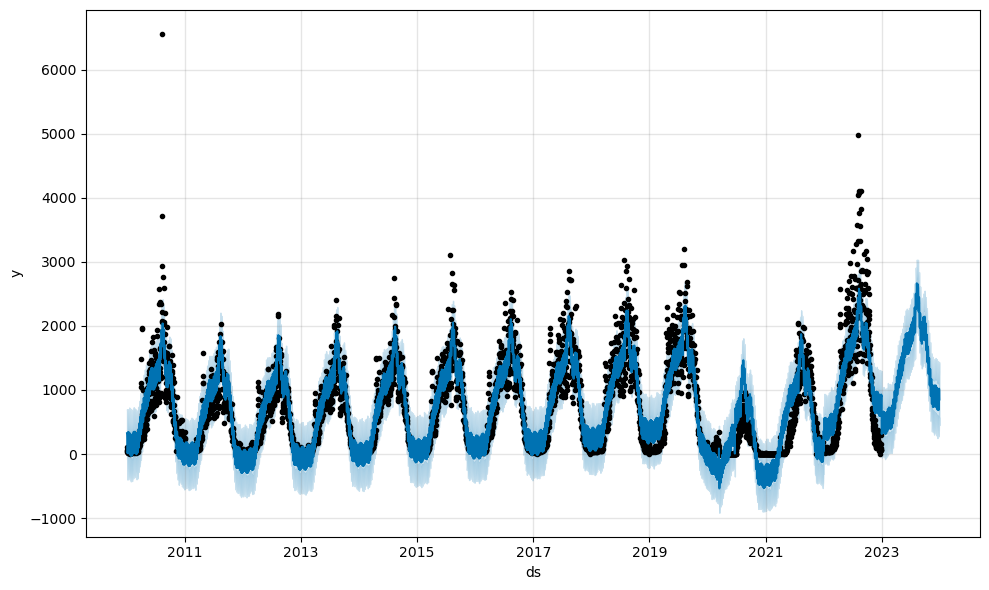

In [31]:
modelo2.plot(prevision2);

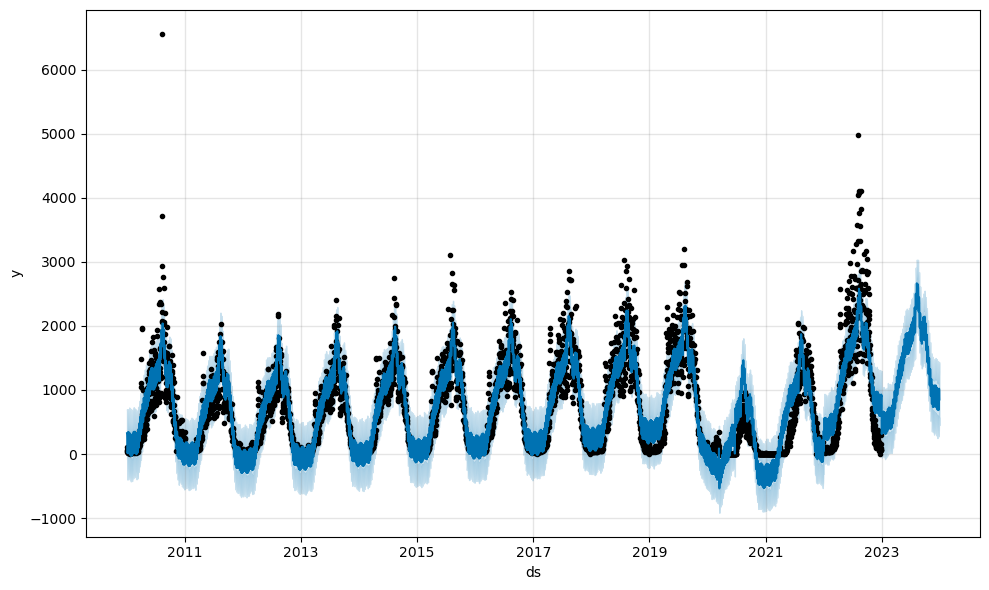

In [32]:
modelo.plot(prevision2);

/opt/anaconda3/lib/python3.9/site-packages/prophet/forecaster.py:896: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  components = components.append(new_comp)
/opt/anaconda3/lib/python3.9/site-packages/prophet/forecaster.py:896: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  components = components.append(new_comp)


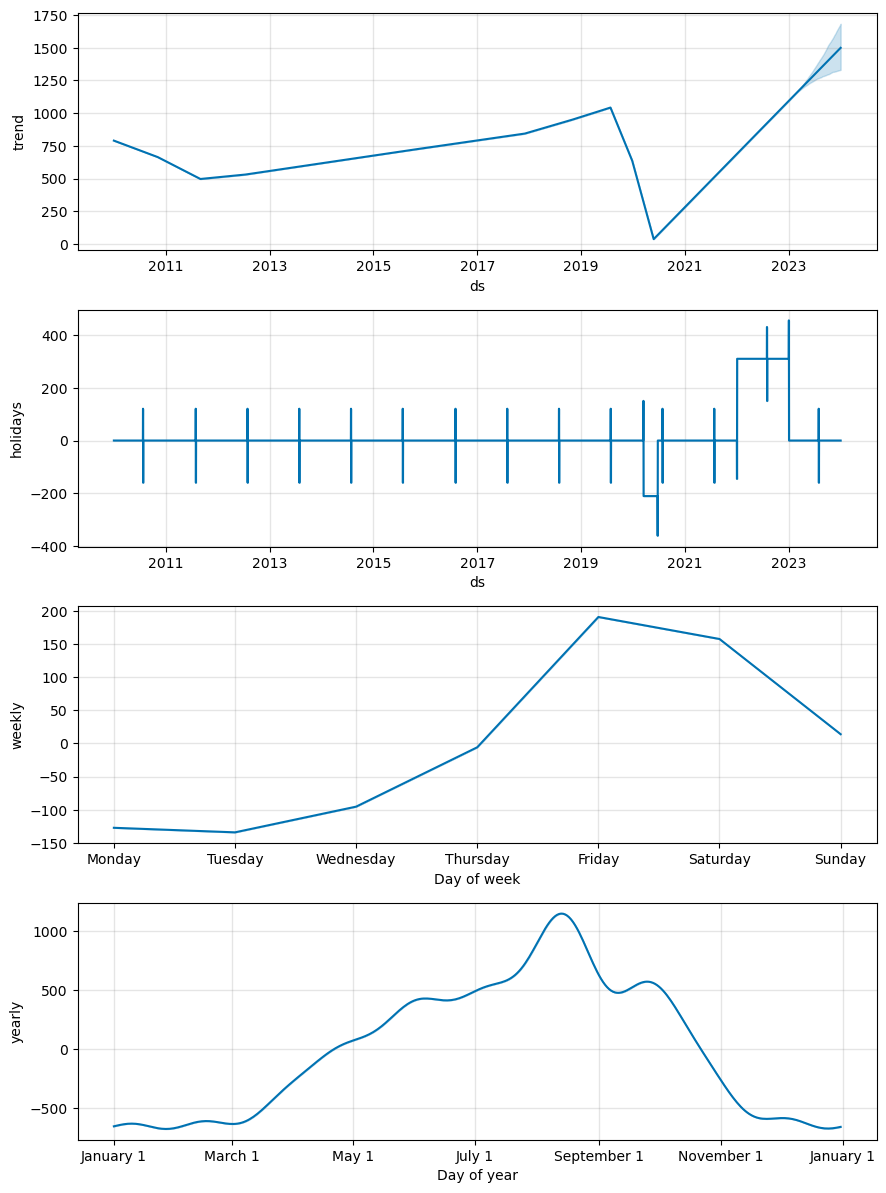

In [33]:
modelo2.plot_components(prevision2, weekly_start=1);

In [34]:
modelo.params


{'k': array([[-0.23069376]]),
 'm': array([[0.11794359]]),
 'delta': array([[-7.72135860e-08, -2.10267200e-01, -2.31078466e-07,
          5.28363788e-01,  8.77661719e-08,  2.89362511e-02,
         -4.88219746e-08,  1.04463919e-07, -6.43901183e-08,
          7.26075846e-10, -2.42132544e-07, -6.43789949e-05,
         -1.33681293e-04, -1.57635335e-07, -2.37839717e-07,
         -2.02329573e-07,  4.97728703e-03,  2.51962368e-08,
          7.01458681e-02,  4.43748076e-06,  2.98391311e-03,
          2.88205110e-01, -2.43488304e+00, -1.74035825e+00,
          4.89121131e+00]]),
 'sigma_obs': array([[0.0442888]]),
 'beta': array([[-0.04626343, -0.10691684,  0.01910638, -0.00768637,  0.00357367,
          0.01467558,  0.00594194, -0.00135376, -0.00123367,  0.0086391 ,
         -0.00892426, -0.00875857,  0.00627475, -0.00141438,  0.00030393,
          0.00553159, -0.00154136, -0.00395536,  0.00498031,  0.00105661,
          0.02491014,  0.0066044 ,  0.00163735, -0.00520826,  0.00171961,
         

In [35]:
modelo2.params

{'k': array([[-0.2937558]]),
 'm': array([[0.12042508]]),
 'delta': array([[-5.85163480e-07, -1.11192816e-01,  2.39509354e-07,
          4.80674655e-01,  7.05056529e-08,  4.12445449e-02,
          3.30582658e-07, -5.49978142e-08, -2.48680646e-07,
         -2.18628826e-07,  4.81822555e-08, -8.87614837e-07,
         -4.00574595e-03, -5.51727716e-07,  4.31769031e-08,
          6.16917533e-08,  2.20284506e-08, -2.82611892e-07,
          1.15497016e-01,  1.16134213e-06,  1.77348416e-02,
          6.68922566e-03, -2.17101448e+00, -9.54416788e-01,
          3.67760130e+00]]),
 'sigma_obs': array([[0.04447573]]),
 'beta': array([[-4.70682852e-02, -1.07032780e-01,  1.77813888e-02,
         -7.91827742e-03,  3.03529186e-03,  1.49873089e-02,
          5.53855458e-03, -1.23920681e-03, -1.26857849e-03,
          8.78238725e-03, -9.21382084e-03, -8.99753657e-03,
          6.04608729e-03, -1.32189260e-03, -1.88879435e-05,
          5.49689945e-03, -1.61288219e-03, -3.75815985e-03,
          4.8798474

In [77]:
df_datos_f = df_datos
df_datos_f['cap']= 0
df_datos_f['floor']= -7500


futuro_f =futuro
futuro_f['cap']=0
futuro_f['floor']=-7500



In [ ]:
df

In [78]:

modelo3 = Prophet(growth='logistic' ,holidays=dias_especiales )



In [79]:
prevision3 = modelo3.fit(df_datos_f).predict(futuro_f)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/opt/anaconda3/lib/python3.9/site-packages/prophet/forecaster.py:896: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  components = components.append(new_comp)


Initial log joint probability = -33.1891
    Iter      log prob        ||dx||      ||grad||       alpha      alpha0  # evals  Notes 
      99       12327.3     0.0241515       762.125           1           1      119   
    Iter      log prob        ||dx||      ||grad||       alpha      alpha0  # evals  Notes 
     199         12351    0.00378624       425.095      0.3561      0.3561      233   
    Iter      log prob        ||dx||      ||grad||       alpha      alpha0  # evals  Notes 
     299       12361.3     0.0037949       239.031           1           1      361   
    Iter      log prob        ||dx||      ||grad||       alpha      alpha0  # evals  Notes 
     399       12365.2    0.00408566       154.913           1           1      477   
    Iter      log prob        ||dx||      ||grad||       alpha      alpha0  # evals  Notes 
     499       12372.6    0.00103802       117.021      0.3476           1      608   
    Iter      log prob        ||dx||      ||grad||       alpha  

/opt/anaconda3/lib/python3.9/site-packages/prophet/forecaster.py:896: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  components = components.append(new_comp)
/opt/anaconda3/lib/python3.9/site-packages/prophet/forecaster.py:896: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  components = components.append(new_comp)


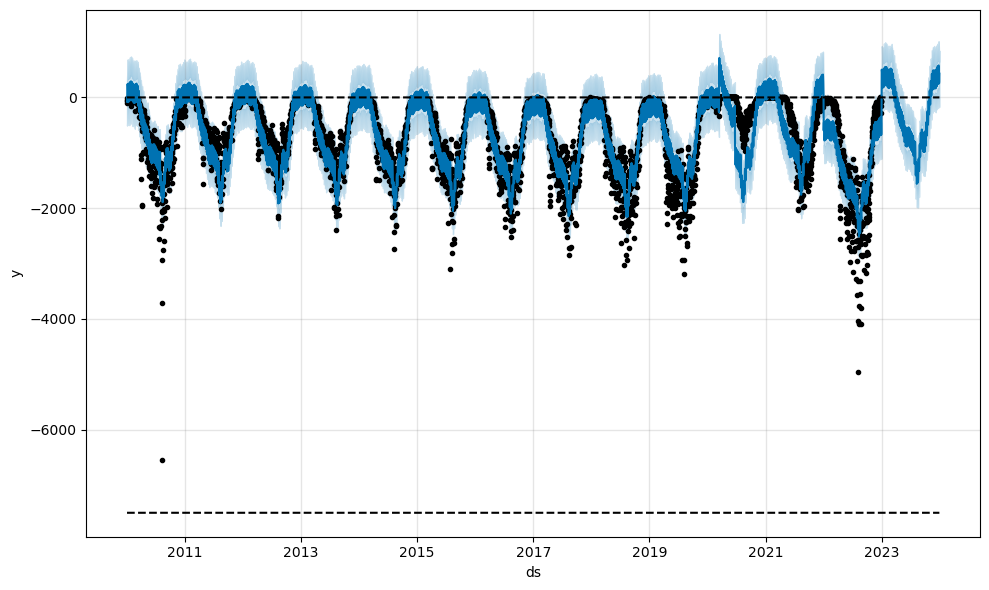

In [80]:
modelo3.plot(prevision3);


/opt/anaconda3/lib/python3.9/site-packages/prophet/forecaster.py:896: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  components = components.append(new_comp)
/opt/anaconda3/lib/python3.9/site-packages/prophet/forecaster.py:896: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  components = components.append(new_comp)


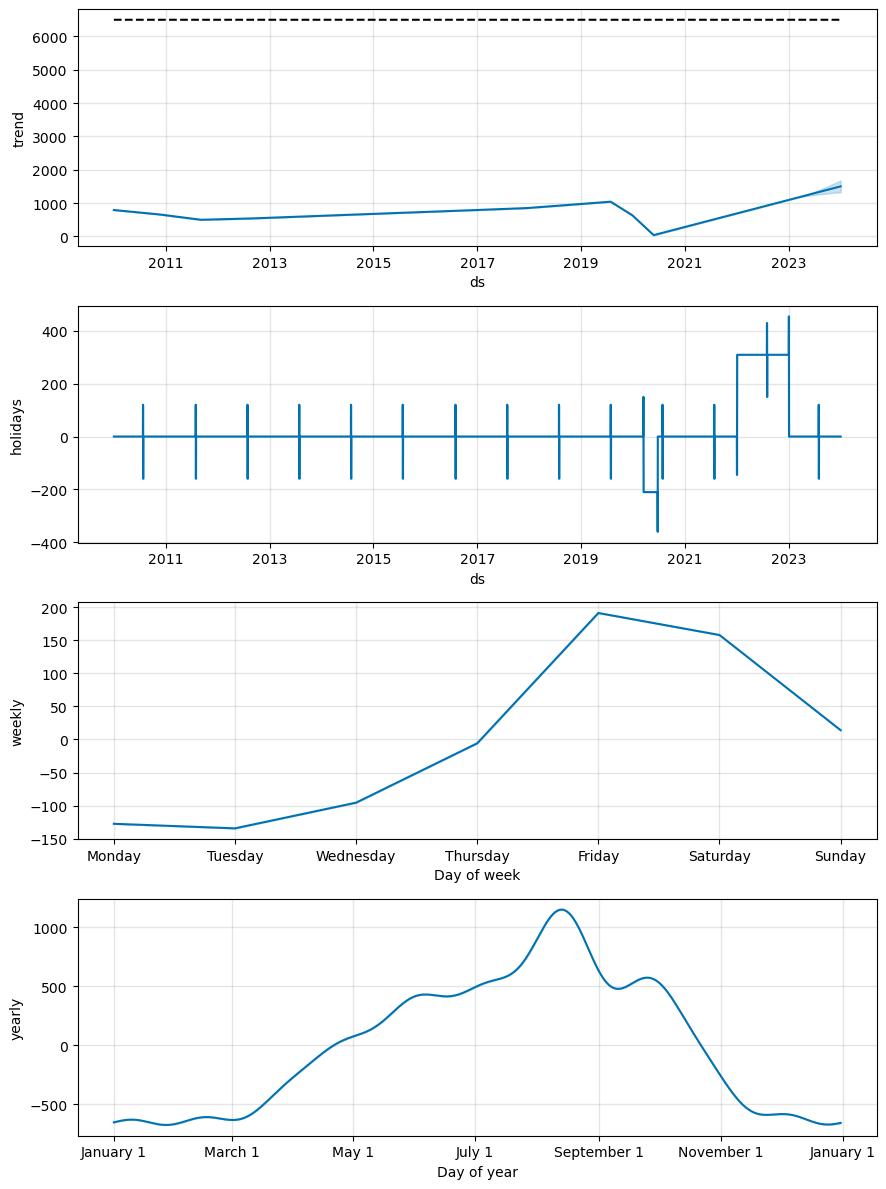

In [59]:
modelo3.plot_components(prevision3, weekly_start=1);

In [60]:
model = pd.DataFrame()

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/opt/anaconda3/lib/python3.9/site-packages/prophet/forecaster.py:896: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  components = components.append(new_comp)
/opt/anaconda3/lib/python3.9/site-packages/prophet/forecaster.py:896: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  components = components.append(new_comp)
/opt/anaconda3/lib/python3.9/site-packages/prophet/forecaster.py:896: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  components = components.append(new_comp)


Initial log joint probability = -237.44
    Iter      log prob        ||dx||      ||grad||       alpha      alpha0  # evals  Notes 
      38       7495.86   4.21006e-07       100.094      0.8441      0.8441       52   
Optimization terminated normally: 
  Convergence detected: relative gradient magnitude is below tolerance


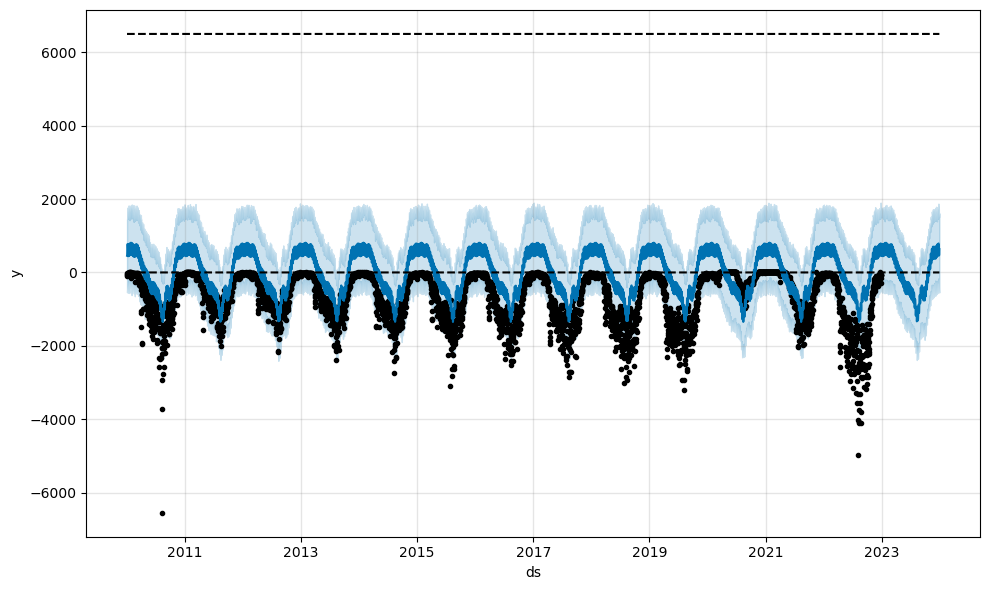

In [61]:
df_datos_f['y'] = 10 - df_datos_f['y']
df_datos_f['cap'] = 6500
df_datos_f['floor'] = 0
futuro['cap'] = 6500
futuro['floor'] = 0
m = Prophet(growth='logistic')
m.fit(df_datos_f)
fcst = m.predict(futuro)
fig = m.plot(fcst)